In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

from utils import frequency_encode, plot_columns, ploting_cnt_amt 

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
LEGIT_C, FRAUD_C = "#3E6FB0", "#D64550"
INK, MUTED, GRID = "#22303C", "#5b6b78", "#e9edf1"
SEED = 42
CONFIG = {
    "sample_rows": 80000,
    "gen_rows": 3500,
    "ctgan_epochs": 20, "diffusion_epochs": 150, "gnn_epochs": 40, "tf_epochs": 12,
    "use_gpu": True, "wandb": False,  # keep False for the live session, avoids a login prompt
}

In [4]:
project_root = Path.cwd().parents[1]
df_train_transaction = pd.read_csv(project_root / 'data' / 'raw' / 'train_transaction.csv')
df_train_identity    = pd.read_csv(project_root / 'data' / 'raw' / 'train_identity.csv')
df = df_train_transaction.merge(df_train_identity, on='TransactionID', how='left')

print(f'Transaction table: {df_train_transaction.shape}')
print(f'Identity table:    {df_train_identity.shape}')
print(f'Merged:            {df.shape}')

Transaction table: (590540, 394)
Identity table:    (144233, 41)
Merged:            (590540, 434)


# Data Cleaning

Drop nan columns, save freq encoded columns from EDA, clean email provider for google, yahoo and microsoft

In [5]:
# > 90% NaN
columns_to_drop = [
    'id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'dist2', 'D7', 'id_18'
    # "C10", "C11", "C12", 'C14', 'C2', 'C4', 'C6', 'C7', 'C8', 'D12', 'D2', 'D6', 'D7', 'D9'
]
FREQ_ENCODE_COLS = [
    "card1", "card2", "card3", "card5",
    "addr1", "addr2",
    "DeviceInfo",
    "id_13", "id_14", "id_17", "id_19", "id_20",
    "id_26", "id_30", "id_31", "id_33",
]
RARE_EMAIL_MIN_COUNT = 500

def provider(x):
    x = str(x)
    if "gmail" in x: 
        return "google"
    if "yahoo" in x: 
        return "yahoo"
    if any(k in x for k in ["hotmail","outlook","live","msn"]): 
        return "microsoft"
    return x
for col in ["P_emaildomain", "R_emaildomain"]:
    df[col] = df[col].apply(provider)


In [6]:
df.drop(columns=columns_to_drop, inplace=True)

# Features without a need for train test split

In [7]:
START = pd.Timestamp("2017-12-01")
df["dt"] = START + pd.to_timedelta(df["TransactionDT"], unit="s")
df["hour"] = df["dt"].dt.hour.astype(np.int8)
df["dayofweek"] = df["dt"].dt.dayofweek.astype(np.int8)
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24).astype(np.float32)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24).astype(np.float32)
df = df.sort_values("TransactionDT").reset_index(drop=True)

df["amt_log"] = np.log1p(df["TransactionAmt"]).astype(np.float32)
df["amt_cents"] = ((df["TransactionAmt"] - np.floor(df["TransactionAmt"]))*100).round().astype(np.int16)
df["amt_is_round"] = (df["amt_cents"] == 0).astype(np.int8)

C:\Users\zheng\AppData\Local\Temp\ipykernel_5008\43661281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dt"] = START + pd.to_timedelta(df["TransactionDT"], unit="s")
C:\Users\zheng\AppData\Local\Temp\ipykernel_5008\43661281.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour"] = df["dt"].dt.hour.astype(np.int8)
C:\Users\zheng\AppData\Local\Temp\ipykernel_5008\43661281.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [8]:
df_clean = df.sort_values("TransactionDT").reset_index(drop=True)
cut = int(len(df_clean) * 0.8)
train_df = df_clean.iloc[:cut].copy()
test_df = df_clean.iloc[cut:].copy()
print("train", train_df.shape, "test", test_df.shape,
      "test fraud rate", round(float(test_df["isFraud"].mean()), 4))

train (472432, 430) test (118108, 430) test fraud rate 0.0344


## Frequency encoding — fit counts on train, map onto test
Values seen only in test (never in train) map to NaN, filled with 0 — the model reads that
as "unseen category", not an in-train rare value.

In [9]:
for col in FREQ_ENCODE_COLS:
    if col not in train_df.columns:
        continue
    train_counts = train_df[col].value_counts()
    new_col = f"{col}_freq"
    train_df[new_col] = train_df[col].map(train_counts).astype(np.float32)
    test_df[new_col] = test_df[col].map(train_counts).fillna(0).astype(np.float32)

## Email match + rare-domain binning
`email_match` doesn't need train/test fitting (it's a row-local comparison, no leakage risk).
The rare-domain threshold does — "rare" is defined by train counts, then applied to test.

In [10]:


for d in (train_df, test_df):
    d["email_match"] = (d["P_emaildomain"] == d["R_emaildomain"]).astype(np.int8)

for col in ["P_emaildomain", "R_emaildomain"]:
    train_counts = train_df[col].value_counts()
    rare = train_counts[train_counts < RARE_EMAIL_MIN_COUNT].index

    new_col = f"{col}_binned"
    train_df[new_col] = train_df[col].where(~train_df[col].isin(rare), "Others")
    # any test-only domain (not in train_counts at all) is also unseen -> Others
    test_df[new_col] = test_df[col].where(test_df[col].isin(train_counts.index) & ~test_df[col].isin(rare), "Others")

print(train_df["P_emaildomain_binned"].value_counts().head())

P_emaildomain_binned
google           183103
yahoo             82465
nan               73586
microsoft         48667
anonymous.com     29961
Name: count, dtype: int64


## Encode remaining object columns — categories fit on train, applied to test
Anything still `object` dtype (`ProductCD`, `card4`, `card6`, `M1-M9`, low-cardinality
`id_` flags, `DeviceType`, `P_provider`, the two binned email columns, etc.) needs a
numeric code for LightGBM/XGBoost/CatBoost's sklearn API. Categories are read off train
only; any test-only category maps to -1 (a distinct "unseen" code, not blended into an
existing one).

In [11]:
drop = ["isFraud", "TransactionID", "dt", "TransactionDT", "P_emaildomain", "R_emaildomain",
        "DeviceInfo"]

feature_cols = [c for c in train_df.columns if c not in drop and c not in FREQ_ENCODE_COLS]

object_cols = [c for c in feature_cols
               if train_df[c].dtype == object or pd.api.types.is_string_dtype(train_df[c])]

# keep the code -> original-category mapping per column, so SHAP explanations can show
# "card4 = visa" instead of "card4 = 2" later. The model still trains on the int codes
# below; this dict is only consulted at explanation time, never fed into training.
category_maps = {}
for c in object_cols:
    cats = pd.Categorical(train_df[c]).categories
    category_maps[c] = dict(enumerate(cats))  # {0: "visa", 1: "mastercard", ...}; -1 (unseen) is not in this map
    train_df[c] = pd.Categorical(train_df[c], categories=cats).codes.astype(np.int32)
    test_df[c] = pd.Categorical(test_df[c], categories=cats).codes.astype(np.int32)

X_tr, y_tr = train_df[feature_cols], train_df["isFraud"].astype(np.int8)
X_oot, y_oot = test_df[feature_cols], test_df["isFraud"].astype(np.int8)
print("train", X_tr.shape, "test", X_oot.shape,
      "encoded object cols:", len(object_cols))

train (472432, 427) test (118108, 427) encoded object cols: 25


## Save X_train and X_test

In [12]:
df_train_transaction = pd.read_csv(project_root / 'data' / 'raw' / 'train_transaction.csv')
df_train_identity    = pd.read_csv(project_root / 'data' / 'raw' / 'train_identity.csv')

X_tr.to_csv(project_root / 'data' / 'processed' / 'x_train.csv')
y_tr.to_csv(project_root / 'data' / 'processed' / 'y_train.csv')
X_oot.to_csv(project_root / 'data' / 'processed' / 'x_test.csv')
y_oot.to_csv(project_root / 'data' / 'processed' / 'y_test.csv')

## Train XGBoost, LightGBM, CatBoost on the clean split

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier
from scipy.stats import rankdata

spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

def lgbm(Xt, yt, Xv, w=spw, n=200):
    m = lgb.LGBMClassifier(n_estimators=n, learning_rate=0.05, num_leaves=128, subsample=0.8,
                            colsample_bytree=0.6, scale_pos_weight=w, random_state=SEED, verbose=-1)
    m.fit(Xt, yt)
    return m, m.predict_proba(Xv)[:, 1]

def xgbm(Xt, yt, Xv, w=spw, n=200):
    p = dict(n_estimators=n, learning_rate=0.05, max_depth=8, subsample=0.8, colsample_bytree=0.6,
             scale_pos_weight=w, eval_metric="auc", random_state=SEED)
    if CONFIG["use_gpu"]: p.update(tree_method="hist", device="cuda")
    try:
        m = xgb.XGBClassifier(**p) 
        m.fit(Xt, yt)
    except Exception:
        p.pop("device", None)
        m = xgb.XGBClassifier(**p)
        m.fit(Xt, yt)
    return m, m.predict_proba(Xv)[:, 1]

def catb(Xt, yt, Xv, w=spw, n=200):
    p = dict(iterations=n, learning_rate=0.05, depth=8, scale_pos_weight=w, random_seed=SEED, verbose=0)
    if CONFIG["use_gpu"]: p["task_type"] = "GPU"
    try: m = CatBoostClassifier(**p); m.fit(Xt, yt)
    except Exception: p.pop("task_type", None); m = CatBoostClassifier(**p); m.fit(Xt, yt)
    return m, m.predict_proba(Xv)[:, 1]

lgb_m, lgb_s = lgbm(X_tr, y_tr, X_oot)
xgb_m, xgb_s = xgbm(X_tr, y_tr, X_oot)
cat_m, cat_s = catb(X_tr, y_tr, X_oot)
ens_s = np.mean([rankdata(s) for s in [lgb_s, xgb_s, cat_s]], axis=0); ens_s /= ens_s.max()

scores = {"lightgbm": lgb_s, "xgboost": xgb_s, "catboost": cat_s, "ensemble": ens_s}
for k, s in scores.items():
    print(f"{k:10s} AUC {roc_auc_score(y_oot, s):.4f} | PR AUC {average_precision_score(y_oot, s):.4f}")

c:\Users\zheng\anaconda3\envs\fraud_d\Lib\site-packages\xgboost\core.py:751: UserWarning: [18:06:10] WARNING: D:\bld\xgboost-split_1780806771950\work\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


lightgbm   AUC 0.9110 | PR AUC 0.5194
xgboost    AUC 0.9050 | PR AUC 0.5084
catboost   AUC 0.9079 | PR AUC 0.4960
ensemble   AUC 0.9138 | PR AUC 0.5213


## Save the LightGBM model for SHAP analysis
Saving `lgb_m` (the fitted `LGBMClassifier`, not just its booster) so `SHAPExplainer` and
`predict_proba` both work directly off the reloaded object later, without retraining.

In [14]:
import joblib

model_dir = project_root / "src" / "model" / "artifacts"
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(lgb_m, model_dir / "lgb_model.joblib")
joblib.dump(feature_cols, model_dir / "feature_cols.joblib")
print("saved to", model_dir / "lgb_model.joblib")

saved to c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\model\artifacts\lgb_model.joblib


# SHAP analysis

Reuses `SHAPExplainer` from `src/model/explain.py` (already implemented — wraps
`shap.TreeExplainer`, converts raw SHAP vectors into business-labeled dicts via
`FEATURE_LABELS`). No need to re-derive that logic here.

In [15]:
import sys
sys.path.append(str(project_root))
from src.model.explain import SHAPExplainer

explainer = SHAPExplainer(lgb_m, feature_names=feature_cols, category_maps=category_maps)

In [16]:
X_oot.sample(5)

,TransactionAmt,ProductCD,card4,card6,dist1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_12,id_15,id_16,id_28,id_29,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,hour,dayofweek,hour_sin,hour_cos,amt_log,amt_cents,amt_is_round,card1_freq,card2_freq,card3_freq,card5_freq,addr1_freq,addr2_freq,DeviceInfo_freq,id_13_freq,id_14_freq,id_17_freq,id_19_freq,id_20_freq,id_30_freq,id_31_freq,id_33_freq,email_match,P_emaildomain_binned,R_emaildomain_binned
566726,22.871,0,3,2,NaN,1.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.875,0.875,0.0,NaN,0.0,0.0,494.0,0.0,-1,-1,-1,2,-1,-1,-1,-1,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,47.3396,47.3396,47.3396,0.0,0.0,0.0,0.0,0.0,0.0,47.3396,47.3396,47.3396,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,3.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,1.0,47.3396,82.690598,47.3396,0.0,35.351002,0.0,0.0,0.0,0.0,0.0,47.3396,47.3396,47.3396,0.0,0.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,47.339600,47.339600,47.339600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.3396,47.3396,47.3396,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-95.0,153605.0,0.0,0.0,-1.0,-28.0,0.0,0.0,100.0,1,0,0,0,0,NaN,-1,0,0,1,0,1,21,2,-0.707107,7.071068e-01,3.172664,87,0,276.0,279.0,46539.0,16216.0,0.0,0.0,92.0,0.0,0.0,46267.0

## Global feature importance (beeswarm)
Runs on a sample of the holdout — SHAP on the full 118k-row `X_oot` is slow.

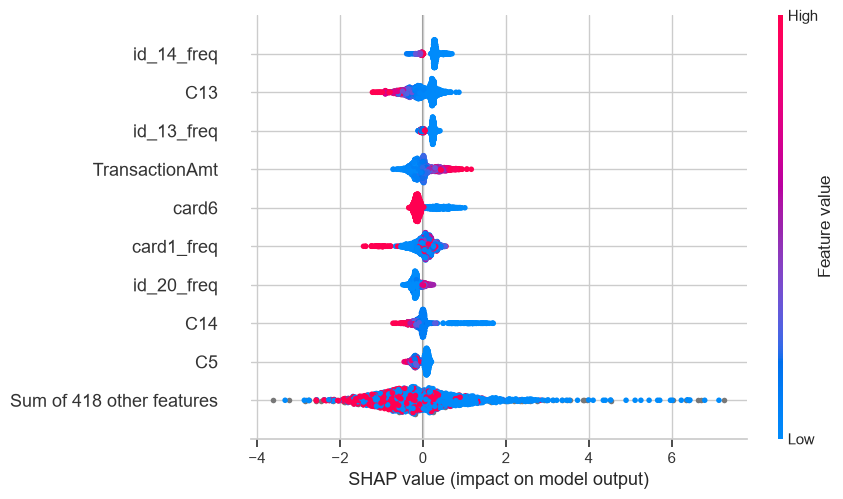

In [17]:
shap_sample = X_oot.sample(n=min(2000, len(X_oot)), random_state=SEED)
explainer.explain_global(shap_sample, max_display=20)

## Explain a single transaction
Picks a true-fraud row from `X_oot` that the model actually flagged (fraud_prob >= 0.5),
so the explanation corresponds to a real correct catch rather than an arbitrary row.

In [18]:
oot_fraud = X_oot[y_oot == 1]
oot_fraud_probs = lgb_m.predict_proba(oot_fraud)[:, 1]
caught_fraud = oot_fraud[oot_fraud_probs >= 0.5]

example_txn_id = caught_fraud.index[2]
example_row = X_oot.loc[example_txn_id]
fraud_prob = float(lgb_m.predict_proba(example_row.to_frame().T)[:, 1][0])

shap_dicts = explainer.explain_transaction(example_row, top_n=10)
print(explainer.format_for_llm(shap_dicts, fraud_prob))

Fraud probability: 0.785 (78.5%)

Top contributing factors:
  1. Masked counting info C14 = 0.00 [↑ fraud, SHAP=+1.2890]
  2. How common this value is in the training data (Network connection / digital signature info id_14) = 0.00 [↑ fraud, SHAP=+0.5337]
  3. Masked counting info C13 = 0.00 [↑ fraud, SHAP=+0.3979]
  4. Card type (debit/credit/charge) = credit [↑ fraud, SHAP=+0.2986]
  5. addr1_freq = 0.00 [↓ fraud, SHAP=-0.2500]
  6. Time delta (e.g. days since a previous transaction) D12 = 0.00 [↑ fraud, SHAP=+0.1784]
  7. How common this value is in the training data (Card payment information, card type  card3) = 46539.00 [↑ fraud, SHAP=+0.1428]
  8. Masked counting info C5 = 0.00 [↑ fraud, SHAP=+0.1399]
  9. addr2_freq = 0.00 [↓ fraud, SHAP=-0.1355]
  10. Engineered feature (ranking, counting, etc.) V91 = 0.00 [↑ fraud, SHAP=+0.1295]


## Categorical values are now decoded automatically
`SHAPExplainer` was constructed above with `category_maps=category_maps`, so
`explain_transaction`'s output already shows original category labels (e.g. `card6 =
credit`) — no separate decoding step needed anymore. `shap_dicts` below is the same object
returned by the `explain_transaction` call a few cells up.

In [19]:
shap_dicts

[{'feature': 'C14',
  'business_label': 'Masked counting info C14',
  'value': 0.0,
  'shap_contribution': 1.2889814104390114,
  'direction': 'increases_fraud_risk'},
 {'feature': 'id_14_freq',
  'business_label': 'How common this value is in the training data (Network connection / digital signature info id_14)',
  'value': 0.0,
  'shap_contribution': 0.533664676206485,
  'direction': 'increases_fraud_risk'},
 {'feature': 'C13',
  'business_label': 'Masked counting info C13',
  'value': 0.0,
  'shap_contribution': 0.3978755395332068,
  'direction': 'increases_fraud_risk'},
 {'feature': 'card6',
  'business_label': 'Card type (debit/credit/charge)',
  'value': 'credit',
  'shap_contribution': 0.2985821395350049,
  'direction': 'increases_fraud_risk'},
 {'feature': 'addr1_freq',
  'business_label': 'addr1_freq',
  'value': 0.0,
  'shap_contribution': -0.25003377852044834,
  'direction': 'decreases_fraud_risk'},
 {'feature': 'D12',
  'business_label': 'Time delta (e.g. days since a previo

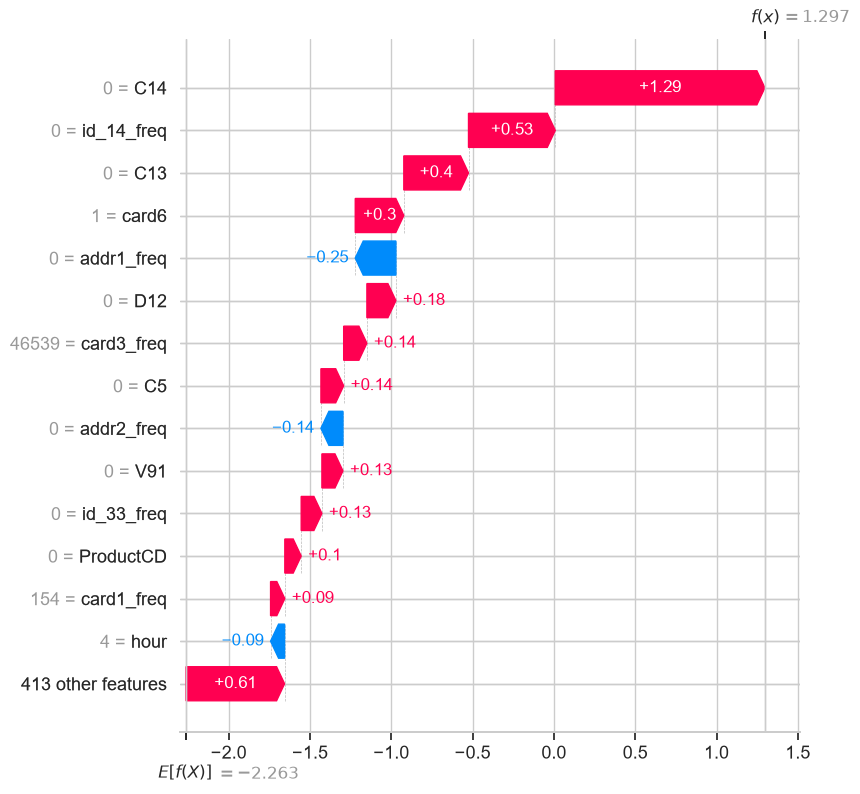

In [20]:
explainer.plot_waterfall(example_row, top_n=15)

# Similar transactions

Reuses `find_similar_fraud`/`_cosine_similarity` from `src/agent/tools.py` (already
implemented — cosine similarity over numeric features against a corpus of confirmed-fraud
rows). `find_similar_fraud` reads its corpus/feature-list off a module-level `ToolContext`,
so `set_tool_context()` still needs to run once here — this just doesn't go through the
`@tool`-wrapped `find_similar_fraud_cases_tool` stub, which needs a transaction_id lookup
that doesn't exist yet.

In [21]:
from src.agent.tools import set_tool_context, find_similar_fraud

# corpus of confirmed fraud, indexed by TransactionID like tools.py expects
fraud_corpus = test_df.loc[X_oot.index[y_oot == 1], feature_cols].copy()
fraud_corpus.index = test_df.loc[fraud_corpus.index, "TransactionID"]

similarity_features = [c for c in feature_cols if X_oot[c].dtype != object]

# all_transactions: lets find_similar_fraud_cases_tool/read_shap_values_tool resolve a
# bare transaction_id string (the only thing the LLM actually passes through a tool call)
# back to a feature row. model: needed to compute fraud_prob for that same lookup.
all_transactions = test_df.set_index("TransactionID")[feature_cols]

set_tool_context(
    explainer=explainer,
    fraud_cases=fraud_corpus,
    similarity_features=similarity_features,
    all_transactions=all_transactions,
    model=lgb_m,
)
print("fraud corpus size:", len(fraud_corpus), "| similarity features:", len(similarity_features))

fraud corpus size: 4064 | similarity features: 427


## Find fraud cases similar to the example transaction
Uses the same `example_row` explained above via SHAP — so you can compare "why the model
flagged it" against "what past confirmed fraud does it resemble."

In [22]:
similar_cases = find_similar_fraud(example_row, top_k=6)
# drop a self-match (example_row is itself in the fraud corpus, so it can rank #1 at similarity 1.0)
similar_cases = [c for c in similar_cases if c["transaction_id"] != int(example_txn_id)][:5]
pd.DataFrame(similar_cases)

,transaction_id,similarity,TransactionAmt,ProductCD,card4,card6,dist1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_12,id_15,id_16,id_28,id_29,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,hour,dayofweek,hour_sin,hour_cos,amt_log,amt_cents,amt_is_round,card1_freq,card2_freq,card3_freq,card5_freq,addr1_freq,addr2_freq,DeviceInfo_freq,id_13_freq,id_14_freq,id_17_freq,id_19_freq,id_20_freq,id_30_freq,id_31_freq,id_33_freq,email_match,P_emaildomain_binned,R_emaildomain_binned
0,3459507,1.000000,59.636,0.0,2.0,1.0,None,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,None,NaN,0.0,NaN,0.0,NaN,NaN,0.0,None,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,-20.0,196094.0,NaN,NaN,0.0,0.0,NaN,NaN,100.0,1.0,1.0,1.0,1.0,1.0,None,-1.0,0.0,0.0,1.0,0.0,0.0,4.0,5.0,0.866025,

# Agent pipeline: justify the prediction end-to-end

Runs `example_txn_id` through the full `main_agent -> judge` pipeline in
`src/agent/agents.py`. Since `category_maps` is now wired into `explainer`, the SHAP
subagent's tool output (`read_shap_values_tool` -> `get_shap_explanation` ->
`format_for_llm`) already shows decoded category labels (e.g. `card6 = credit`) rather
than raw codes — so the agent's final justification should too, without any extra work
here.

Requires Ollama running locally with the model configured in `OLLAMA_MODEL`
(`src/agent/agents.py`) pulled.

In [24]:
from src.agent.agents import investigate

# example_txn_id is X_oot's row-position index (test_df's post-reset_index position),
# not the real TransactionID column — all_transactions/tools.py are keyed by the actual
# TransactionID, so it must be resolved via test_df before calling investigate().
real_transaction_id = int(test_df.loc[example_txn_id, "TransactionID"])

justification = investigate(str(real_transaction_id))
print(justification)

**Verdict:** Strong case for fraudulent activity based on high model confidence and near-identical matches to confirmed fraud patterns.

**Supporting Evidence:**
*   **High Risk Model Score (78.5%):** Driven primarily by unseen digital signature information (id_14) and zero values in key counters (C13, C14), indicating no prior history for this activity combination compared to legitimate users.
*   **Exact Pattern Matches:** Five confirmed-fraud transactions found with extremely high similarity scores (0.9989–1.0), sharing specific attributes like ProductCD=0, matching device types, and consistent binary V features set to 1.0.
*   **Card Type Correlation:** The use of this specific credit card type increases suspicion based on historical patterns in the model's training period where it was more commonly associated with fraud.

**Contradictions & Gaps:**
*   **Conflicting Signals within SHAP:** While risk indicators dominate, benign signals exist (addresses addr1 and addr2 have appeared